In [1]:
import sys
import os
sys.path.append("/data/shared/fangzy/project/spMAE/github_code/spMAE/spMAE")
import wandb
import torch
import numpy as np
import scanpy as sc
import pytorch_lightning as pl
from dataloader import spDataModule, lsiTransformer, apply_sgc_pure, TFIDF, process_adata_for_training
from model import spMAE_Lightning
from pytorch_lightning.loggers import WandbLogger
from evaluate import evaluate, db_sil, pas_chaos
from util import mclust_R, dopca

In [2]:
i = "E18_5-S1"
pl.seed_everything(42, workers=True)

Seed set to 42


42

In [3]:
adata = sc.read_h5ad("/data/shared/fangzy/data/st_multi_omics/anndata/mouseembryo/"+i+"/rna_pca.h5ad")

adata1 = sc.read_h5ad("/data/shared/fangzy/data/st_multi_omics/anndata/mouseembryo/"+i+"/atac_lsi.h5ad")
smooth_x, adj = apply_sgc_pure(adata,  k_neighbors=4, n_layers=1)
smooth_x1, adj = apply_sgc_pure(adata1, k_neighbors=4, n_layers=1)
x_rna, x_atac, y, n_classes = process_adata_for_training(adata, adata1, label_key="cell_type")

N_GENES = adata.shape[1]
N_ATAC = adata1.shape[1]
N_CLASSES = len(adata.obs["cell_type"].unique())
max_epochs=10
data_module = spDataModule(x_rna, x_atac,  smooth_x, smooth_x1, adata.obsm["spatial"], y, batch_size=1024)
mask_prob = torch.cat([torch.full((10,), 0.1), torch.full((10,), 0.2),torch.full((30,), 0.3)])

--- SGC Smoothing ---
Using global kNN graph: k=4
Average number of neighbors: 5.00
--- SGC Smoothing ---
Using global kNN graph: k=4
Average number of neighbors: 5.00
 - RNA shape: (2129, 50)
 - ATAC shape: (2129, 50)
 - Number of classes: 14


In [4]:

# ---------------------------
# 3. 初始化 Lightning Module
# --------------------------- 
model = spMAE_Lightning(
    num_feat1=N_GENES,
    num_feat2=N_ATAC,
    n_classes=N_CLASSES,
    hidden_size=128,
    lr=1e-3,
    mask_prob_rna=mask_prob,
    mask_prob_atac=mask_prob,
    epochs=max_epochs,
    mask_loss_weight=0.7,
    masked_data_weight=0.7,
    save_path=None
)

wandb_logger = WandbLogger(project="spMAE", name=f"embryo{i}_test", 
                        save_dir="/data/shared/fangzy/results/spMAE/wandb/")

In [5]:
trainer = pl.Trainer(
    max_epochs=max_epochs,
    accelerator='auto',
    devices=1,
    deterministic=True,
    logger=wandb_logger, 
    enable_checkpointing=False,
    enable_progress_bar=True,
    check_val_every_n_epoch=None
)
trainer.fit(model, data_module)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/fangzy/miniconda3/envs/py3.10/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ spMAE              │  223 K │ train │     0 │
│ 1 │ clip_loss_fn │ CrossModalCLIPLoss │      1 │ train │     0 │
└───┴──────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 223 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 223 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/fangzy/miniconda3/envs/py3.10/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/fangzy/miniconda3/envs/py3.10/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/home/fangzy/miniconda3/envs/py3.10/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▂▃▃▄▅▆▆▇█
train/loss_atac_mask,█▅▃▂▂▁▁▁▁▁
train/loss_atac_recon,█▆▄▃▂▂▂▁▁▁
train/loss_clip,█▅▄▃▃▂▂▂▁▁
train/loss_rna_mask,█▅▄▃▂▁▁▁▁▁
train/loss_rna_recon,█▇▅▄▄▃▃▂▁▁
train/loss_total,█▅▄▃▂▂▂▁▁▁
trainer/global_step,▁▂▃▃▄▅▆▆▇█
epoch,9
train/loss_atac_mask,0.37657
train/loss_atac_recon,0.02281


In [6]:

features = model.get_latents(data_module.val_dataloader()) 
latent_fused = features['latent_fused']
labels = y
spatial = adata.obsm["spatial"]

In [7]:
# PCA + mclust
all_latents_pca = dopca(latent_fused, dim=20)
pred_labels_mclust = mclust_R(all_latents_pca, N_CLASSES)


if (labels >= 0).any():
    nmi1, ari1, hom1, ami1 = evaluate(labels, pred_labels_mclust)
    print(f" ARI: {ari1:.4f}")
    

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%
 ARI: 0.5515


In [ ]:
# pas, chaos = pas_chaos(pred_labels_mclust, spatial)

In [8]:
adata.obs["pred_spMAE"] = pred_labels_mclust
adata.obs["pred_spMAE"] = adata.obs["pred_spMAE"].astype("category")

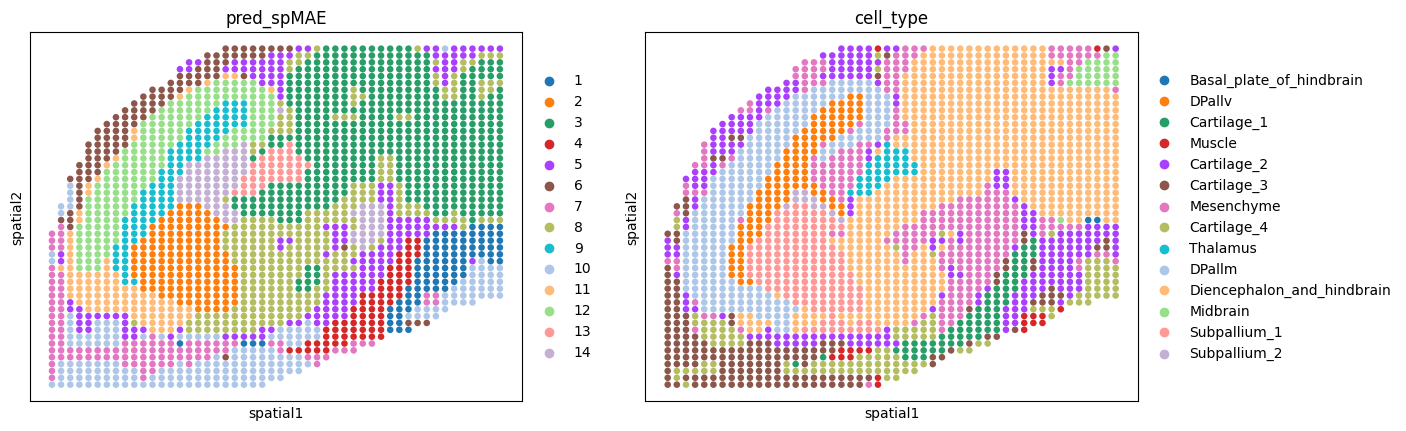

In [9]:
sc.pl.embedding(adata, basis="spatial", color=["pred_spMAE", "cell_type"],size=90)